100%|██████████| 26.4M/26.4M [00:01<00:00, 18.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 306kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.60MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.5MB/s]


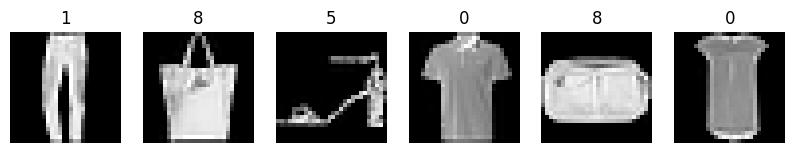

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.figure(figsize=(10,4))
for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"{labels[i].item()}")
    plt.axis('off')
plt.show()


In [ ]:
normal_class = 0  # T-shirt/top
train_selected = [x for x in train_dataset if x[1] == normal_class]


In [ ]:
test_selected = [x for x in test_dataset]


In [ ]:
from torch.utils.data import DataLoader
train_loader = DataLoader(train_selected, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_selected, batch_size=64, shuffle=False)


Epoch 1, Loss: 0.0563
Epoch 2, Loss: 0.0299
Epoch 3, Loss: 0.0233
Epoch 4, Loss: 0.0164
Epoch 5, Loss: 0.0174


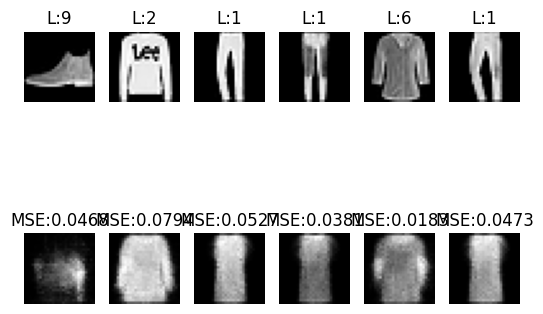

In [ ]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1,16,3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(16,32,3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(32,64,7)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64,32,7),
            nn.ReLU(),
            nn.ConvTranspose2d(32,16,3,stride=2,padding=1,output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16,1,3,stride=2,padding=1,output_padding=1),
            nn.Sigmoid()
        )
    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(5):
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, imgs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        loss_vals = ((outputs - imgs)**2).mean(dim=(1,2,3))
        for i in range(6):
            plt.subplot(2,6,i+1)
            plt.imshow(imgs[i].cpu().squeeze(), cmap='gray')
            plt.title(f"L:{labels[i].item()}")
            plt.axis('off')
            plt.subplot(2,6,i+7)
            plt.imshow(outputs[i].cpu().squeeze(), cmap='gray')
            plt.title(f"MSE:{loss_vals[i]:.4f}")
            plt.axis('off')
        plt.show()
        break


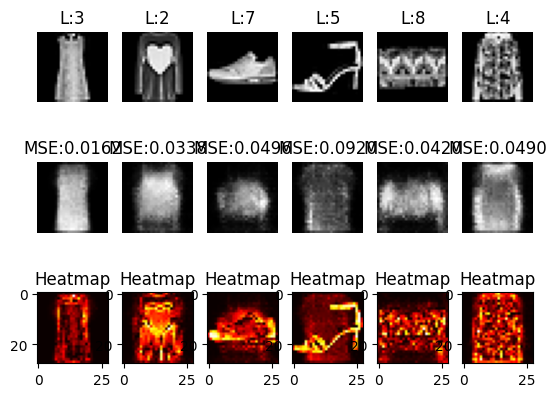

In [ ]:
import numpy as np

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        loss_vals = ((outputs - imgs)**2).mean(dim=(1,2,3))
        for i in range(6):
            input_img = imgs[i].cpu().squeeze()
            output_img = outputs[i].cpu().squeeze()
            heatmap = (input_img - output_img).abs().numpy()
            plt.subplot(3,6,i+1)
            plt.imshow(input_img, cmap='gray')
            plt.title(f"L:{labels[i].item()}")
            plt.axis('off')
            plt.subplot(3,6,i+7)
            plt.imshow(output_img, cmap='gray')
            plt.title(f"MSE:{loss_vals[i]:.4f}")
            plt.axis('off')
            plt.subplot(3,6,i+13)
            plt.imshow(heatmap, cmap='hot')
            plt.title("Heatmap")


FileUpload(value={}, accept='image/*', description='Upload')

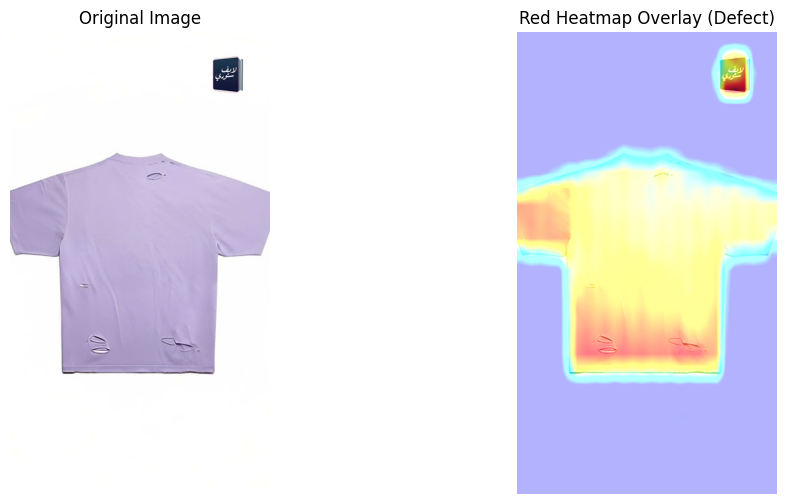

In [ ]:
from IPython.display import display
from ipywidgets import FileUpload
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------
# دالة تحويل الصورة للحجم 28x28 grayscale للـ Autoencoder
# ------------------------------
transform_test = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((28,28)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

# ------------------------------
# رفع الصورة من الجهاز
# ------------------------------
upload_widget = FileUpload(accept='image/*', multiple=False)
display(upload_widget)

def process_uploaded(change):
    if len(upload_widget.value) == 0:
        return

    uploaded_file = list(upload_widget.value.values())[0]
    content = uploaded_file['content']
    nparr = np.frombuffer(content, np.uint8)
    bgr = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    h_orig, w_orig = rgb.shape[:2]

    # تحويل الصورة 28x28 grayscale للـ Autoencoder
    img_tensor = transform_test(rgb).unsqueeze(0).to(device)

    # استخدام الموديل المدرب
    model.eval()
    with torch.no_grad():
        recon = model(img_tensor)

    # استخراج heatmap (فرق مطلق)
    input_img  = img_tensor.cpu().squeeze().numpy()
    output_img = recon.cpu().squeeze().numpy()
    heatmap = np.abs(input_img - output_img)

    # ------------------------------
    # تكبير heatmap لحجم الصورة الأصلي
    # ------------------------------
    heat_resized = cv2.resize(heatmap, (w_orig, h_orig))
    heat_norm = (heat_resized - heat_resized.min()) / (np.ptp(heat_resized) + 1e-8)

    # overlay heatmap زي النسخة الأصلية (الأحمر = أعلى فرق)
    heat_color = cv2.applyColorMap((heat_norm*255).astype(np.uint8), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(rgb, 0.7, heat_color, 0.7, 0)  # 0.7 شفافية اللون الأحمر

    # ------------------------------
    # عرض النتائج

    # ------------------------------
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    plt.imshow(rgb)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(overlay)
    plt.title("Red Heatmap Overlay (Defect)")
    plt.axis('off')
    plt.show()

upload_widget.observe(process_uploaded, names='value')